# MNIST Neural Network Predictin with Tensorflow
Create a predictive model using a sequential neural network with appropriate weights for the MNIST dataset.

## Importing Libraries

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Dense, Flatten

from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

## Load and normalize data

Load the MNIST dataset and normalize the pixel values.


In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = x_train / 255.0
x_test = x_test / 255.0

print("MNIST dataset loaded and normalized.")
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MNIST dataset loaded and normalized.
x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape: (10000, 28, 28)
y_test shape: (10000,)


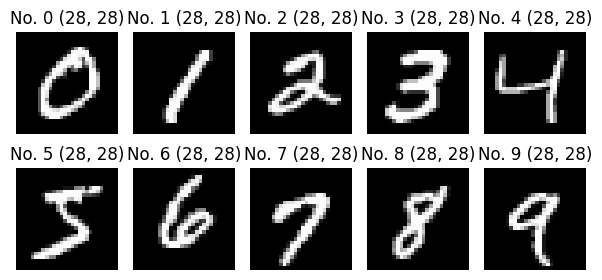

In [ ]:
plt.figure(figsize=(6, 3)) # Create a new figure with a specified size

# this is how we are printing example images from our dataset
for i in range(10): # Loop through each digit from 0 to 9
    # Find the index of the first occurrence of the current digit in the training labels
    digit_index = np.where(y_train == i)[0][0]
    plt.subplot(2, 5, i + 1) # Create a subplot for each digit (2 rows, 5 columns)
    plt.imshow(x_train[digit_index], cmap='gray') # Display the image of the digit
    # Set the title of the subplot to the digit number and image shape
    plt.title(f"No. {i} {x_train[digit_index].shape}")
    plt.axis('off') # Turn off the axis for the subplot
plt.tight_layout() # Adjust the layout to prevent titles/labels from overlapping
plt.show() # Display the plot

## Define model

Define a sequential neural network model.


In [ ]:
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
128*(784+1)

100480

In [ ]:
10*(128+1)

1290

Define a Functioal API neural network model.

In [ ]:
# Define input
inputs = Input(shape=(28, 28))

# Connect layers manually
x = Flatten()(inputs)
x = Dense(128, activation='relu')(x)
outputs = Dense(10, activation='softmax')(x)

# Define the model
model = Model(inputs=inputs, outputs=outputs)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

## Compile model

Compile the model with an appropriate optimizer, loss function, and metrics.


In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

## Train model

Train the model on the training data.


In [ ]:
history = model.fit(x_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9174 - loss: 0.2911 - val_accuracy: 0.9515 - val_loss: 0.1672
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9625 - loss: 0.1282 - val_accuracy: 0.9667 - val_loss: 0.1129
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9735 - loss: 0.0880 - val_accuracy: 0.9691 - val_loss: 0.0996
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9806 - loss: 0.0654 - val_accuracy: 0.9726 - val_loss: 0.0909
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9845 - loss: 0.0509 - val_accuracy: 0.9707 - val_loss: 0.0968
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9875 - loss: 0.0407 - val_accuracy: 0.9734 - val_loss: 0.0895
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9904 - loss: 0.0317 - val_accuracy: 0.9743 - val_loss: 0.0889
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9918 - loss: 0.0256 -

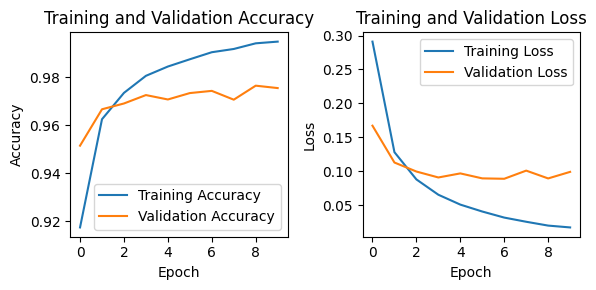

In [ ]:
plt.figure(figsize=(6, 3))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## Evaluate model

Evaluate the model on the test data.

In [ ]:
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Test loss: {loss}")
print(f"Test accuracy: {accuracy}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9784 - loss: 0.0902
Test loss: 0.09021686762571335
Test accuracy: 0.9783999919891357


## Classification Metrics

Compute classification metrics for the model.

In [ ]:
# Get predictions
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Compute classification report
print("Classification Report:")
print(classification_report(y_test, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.95      0.99      0.97      1032
           3       0.98      0.98      0.98      1010
           4       0.99      0.96      0.98       982
           5       0.98      0.98      0.98       892
           6       0.99      0.98      0.98       958
           7       0.98      0.97      0.98      1028
           8       0.98      0.97      0.97       974
           9       0.97      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



## Visualize Confusion Matrix

Visualize the confusion matrix.

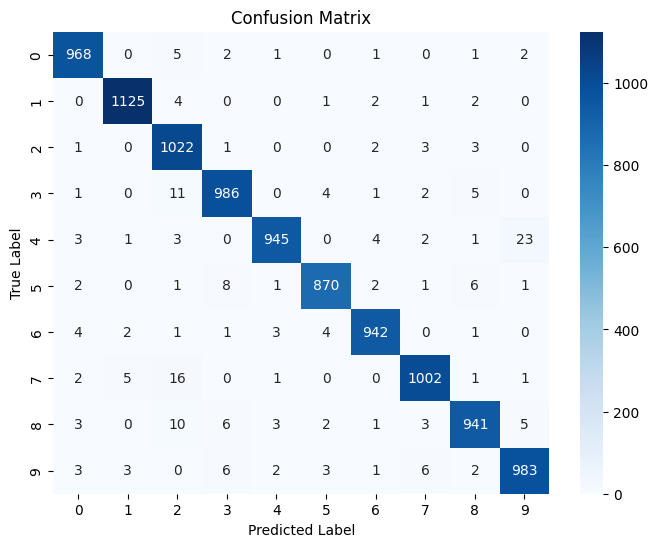

In [ ]:
cm = confusion_matrix(y_test, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 254)            │       199,390 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        32,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 233,320 (911.41 KB)

 Trainable params: 233,320 (911.41 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9315 - loss: 0.2255 - val_accuracy: 0.9543 - val_loss: 0.1433
Epoch 2/10
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9717 - loss: 0.0923 - val_accuracy: 0.9710 - val_loss: 0.0996
Epoch 3/10
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9794 - loss: 0.0639 - val_accuracy: 0.9740 - val_loss: 0.0920
Epoch 4/10
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9843 - loss: 0.0481 - val_accuracy: 0.9776 - val_loss: 0.0806
Epoch 5/10
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9888 - loss: 0.0357 - val_accuracy: 0.9758 - val_loss: 0.0942
Epoch 6/10
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9901 - loss: 0.0307 - val_accuracy: 0.9773 - val_loss: 0.0923
Epoch 7/10
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9920 - loss: 0.0242 - val_accuracy: 0.9786 - val_loss: 0.0861
Epoch 8/10
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9929 - loss: 0.0217

<Axes: >

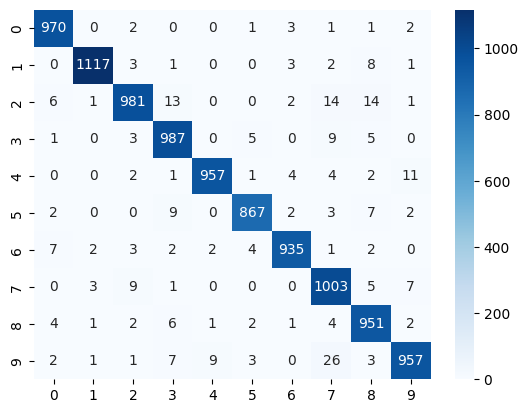

In [ ]:
model2 = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(254, activation='relu'),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model2.summary()
model2.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
history2 = model2.fit(x_train, y_train, epochs=10, validation_split=0.15)
loss, accuracy = model2.evaluate(x_test, y_test)
print(f"Test loss: {loss}")
print(f"Test accuracy: {accuracy}")
# Get predictions
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print("Classification Report:")
print(classification_report(y_test, y_pred_classes))
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

In [ ]:
(60000,28,28)
(60000,28*28)

In [ ]:
# applying logistic regression on MNIST data
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression()
lr.fit(x_train.reshape(-1, 28*28), y_train)
y_pred = lr.predict(x_test.reshape(-1, 28*28))
accuracy_score(y_test, y_pred)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.9257

In [ ]:
784 -> 100

60000,784
60000,100

In [ ]:
# first apply pca getting 100 features then applying logistic regression on MNIST data
from sklearn.decomposition import PCA
pca = PCA(n_components=100)
pca.fit(x_train.reshape(-1, 28*28))

x_train_pca = pca.transform(x_train.reshape(-1, 28*28))
x_test_pca = pca.transform(x_test.reshape(-1, 28*28))

lr = LogisticRegression()
lr.fit(x_train_pca, y_train)
y_pred = lr.predict(x_test_pca)
accuracy_score(y_test, y_pred)

0.9218

In [ ]:
# first apply pca getting 100 features then applying support vector classifier on MNIST data
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

pca = PCA(n_components=100)
pca.fit(x_train.reshape(-1, 28*28))
x_train_pca = pca.transform(x_train.reshape(-1, 28*28))
x_test_pca = pca.transform(x_test.reshape(-1, 28*28))

lr = SVC()
lr.fit(x_train_pca, y_train)
y_pred = lr.predict(x_test_pca)
accuracy_score(y_test, y_pred)

0.9842

1. Apply the feed forward neural network on mnist dataset with 4 layers and compare it with pca + randomforestclassifier